In [2]:
import tensorflow as tf
import numpy as np
import pandas as pd
from pylab import rcParams
import matplotlib.pyplot as plt
import warnings
from mlxtend.plotting import plot_decision_regions
from matplotlib.colors import ListedColormap
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dropout
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_circles
import seaborn as sns

In [4]:
X, y = make_circles(n_samples=100, noise=0.1, random_state=1)

<Axes: >

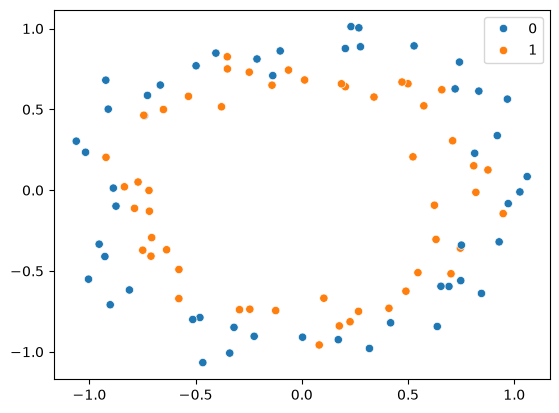

In [5]:
sns.scatterplot(x=X[:, 0], y=X[:, 1], hue=y)

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=2)

In [10]:
model = Sequential()

model.add(Dense(256, input_dim=2, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

In [11]:
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

In [12]:
history = model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=900, verbose=1)

Epoch 1/900
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 162ms/step - accuracy: 0.4875 - loss: 0.6929 - val_accuracy: 0.3500 - val_loss: 0.7016
Epoch 2/900
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.5250 - loss: 0.6903 - val_accuracy: 0.4000 - val_loss: 0.7011
Epoch 3/900
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.5125 - loss: 0.6899 - val_accuracy: 0.4000 - val_loss: 0.7024
Epoch 4/900
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.5125 - loss: 0.6881 - val_accuracy: 0.3500 - val_loss: 0.7042
Epoch 5/900
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.5250 - loss: 0.6877 - val_accuracy: 0.4000 - val_loss: 0.7066
Epoch 6/900
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.5500 - loss: 0.6867 - val_accuracy: 0.4000 - val_loss: 0.7080
Epoch 7/900
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.5625 - loss: 0.6860 - val_accuracy: 0.4000 - val_loss: 0.7086
Epoch 8/900
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.5750 - loss: 0.6854 - val_accuracy: 0.4000 - val_loss

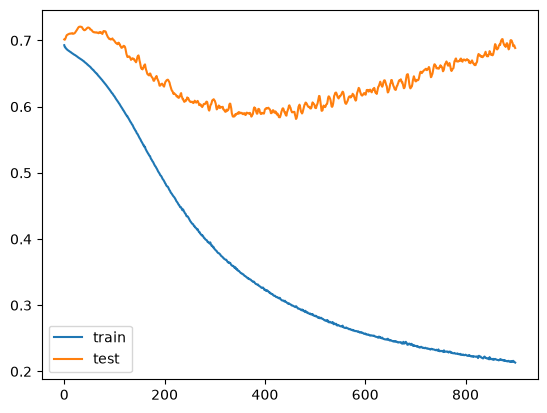

In [13]:
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='test')
plt.legend()
plt.show()

# Early Stopping

In [14]:
model = Sequential()

model.add(Dense(256, input_dim=2, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

In [15]:
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

In [19]:
callback = EarlyStopping(
    monitor="val_loss",
    min_delta=0.000001,
    patience=20,
    verbose=1,
    mode="auto",
    baseline=None,
    restore_best_weights=False
)

In [20]:
history = model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=900, callbacks=callback)

Epoch 1/900
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - accuracy: 0.5500 - loss: 0.6761 - val_accuracy: 0.3500 - val_loss: 0.7207
Epoch 2/900
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.5500 - loss: 0.6759 - val_accuracy: 0.3500 - val_loss: 0.7211
Epoch 3/900
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.5625 - loss: 0.6749 - val_accuracy: 0.3500 - val_loss: 0.7205
Epoch 4/900
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.5625 - loss: 0.6743 - val_accuracy: 0.3500 - val_loss: 0.7198
Epoch 5/900
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.5875 - loss: 0.6737 - val_accuracy: 0.3500 - val_loss: 0.7198
Epoch 6/900
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.5875 - loss: 0.6731 - val_accuracy: 0.3500 - val_loss: 0.7201
Epoch 7/900
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.5875 - loss: 0.6724 - val_accuracy: 0.3500 - val_loss: 0.7194
Epoch 8/900
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.5750 - loss: 0.6719 - val_accuracy: 0.3500 - val_loss:

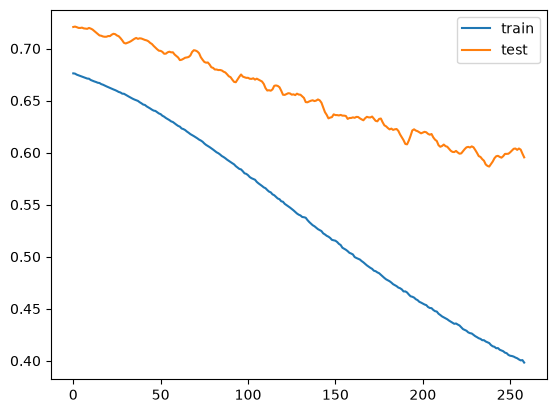

In [21]:
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='test')
plt.legend()
plt.show()